<img src='assets/bricks.jpg'>

In [3]:
import pandas as pd
colors = pd.read_csv('data/colors.csv')

colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [4]:
colors['name'].nunique()

135

In [5]:
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


In [6]:
colors.is_trans.value_counts()

is_trans
f    107
t     28
Name: count, dtype: int64

### *Understanding LEGO Themes vs. LEGO Sets*

Walk into a LEGO store and thy will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.
<img src='assets/lego_themes.png'>

A lego **set** is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.
<img src='assets/lego_sets.png'>


In [7]:
sets = pd.read_csv('data/sets.csv')
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [8]:
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


In [9]:
sets.sort_values('year').head()

,set_num,name,year,theme_id,num_parts
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9534,700.2-1,Large Gift Set (ABB),1949,365,178


In [10]:
sets[sets['year'] == 1949]

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


In [11]:
sets.sort_values('num_parts', ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


In [12]:
import matplotlib.pyplot as plt
sets_by_year = sets.groupby('year').count()

sets_by_year.head()

,set_num,name,theme_id,num_parts
year,,,,
1949,5,5,5,5
1950,6,6,6,6
1953,4,4,4,4
1954,14,14,14,14
1955,28,28,28,28


In [13]:
sets_by_year['set_num'].head()

year
1949     5
1950     6
1953     4
1954    14
1955    28
Name: set_num, dtype: int64

In [14]:
sets_by_year['set_num'].tail()

year
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, dtype: int64

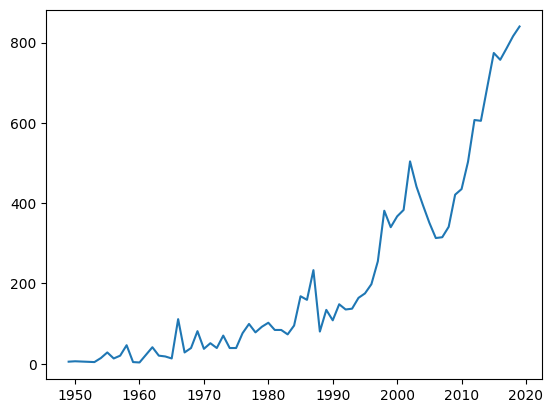

In [15]:
plt.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])

In [17]:
themes_by_year = sets.groupby('year').agg({'theme_id': pd.Series.nunique})

In [18]:
themes_by_year.rename(columns={'theme_id':'nr_themes'}, inplace=True)
themes_by_year.head()

,nr_themes
year,
1949,2
1950,1
1953,2
1954,2
1955,4


In [19]:
themes_by_year.tail()

,nr_themes
year,
2017,89
2018,93
2019,78
2020,82
2021,1


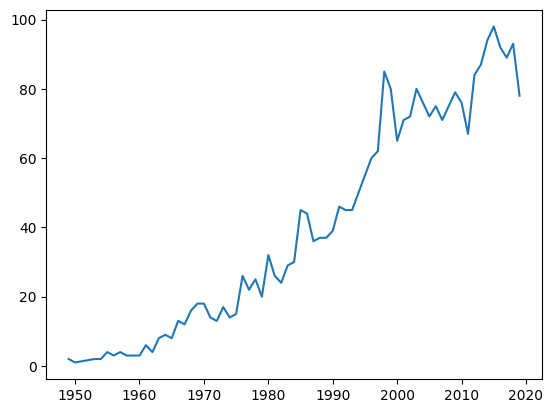

In [20]:
plt.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])

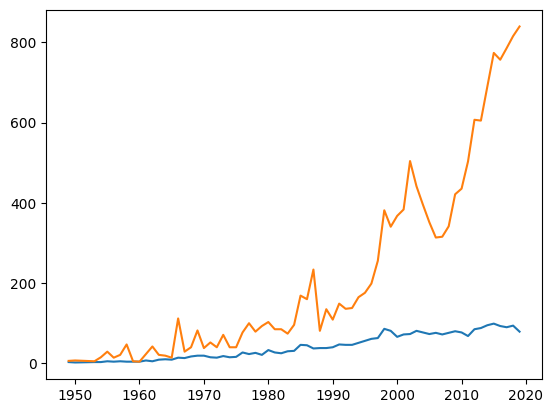

In [ ]:
# Bruh - Different Scales
plt.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])
plt.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])

Text(0, 0.5, 'Number of Themes')

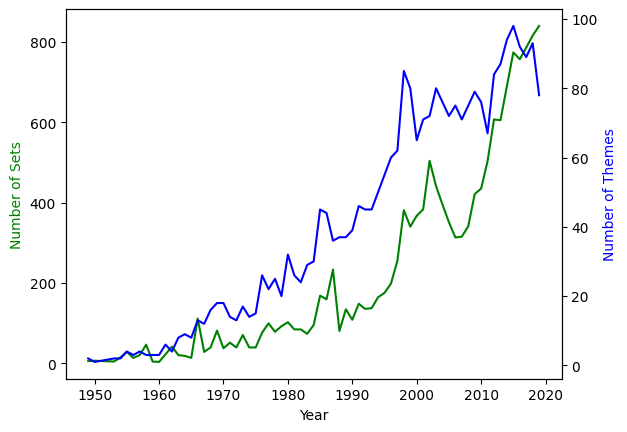

In [22]:
ax_sets = plt.gca()
ax_themes = ax_sets.twinx()

ax_sets.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2], color='g')
ax_themes.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2], 'b')

ax_sets.set_xlabel('Year')
ax_sets.set_ylabel('Number of Sets', color='green')
ax_themes.set_ylabel('Number of Themes', color='blue')